# Political Affiliation Detection on the Archelec Corpus
### ENSAE ML FOR NLP
### Rafaël Mourouvin
---

## Research Questions

**RQ1 — Classification:** *Can we automatically predict the political affiliation of a French legislative candidate from the text of their electoral manifesto?*

**RQ2 — Semantic structure:** *Do politically close parties share a similar rhetorical space? Can we map the French political landscape from manifestos alone?*

**RQ3 — Temporal stability:** *Does political vocabulary remain stable enough across decades to generalise a classifier trained on 1973-1981 to 1988-1993?*

---

## Summary
```
Data (Archelec, 1973-1993)
  → Data cleaning & label engineering
  → EDA: political landscape & vocabulary
  → Preprocessing (leakage removal, language filtering)
  → RQ1: Naive Bayes | TF-IDF+LR | TF-IDF+SVM | LSI+LR | FastText+LR
  → RQ2: LDA topics → named topic map → party semantic map
  → RQ3: temporal split + leave-one-year-out
```


## 0. Setup

In [1]:
!pip install -q wordcloud gensim
print('Ready.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 28.0 MB/s eta 0:00:00
Ready.


In [2]:
import os, re, glob, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from wordcloud import WordCloud
from scipy.spatial.distance import jensenshannon
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import FastText
from gensim.utils import simple_preprocess
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('All imports OK')

All imports OK


## 1. Data Loading

In [3]:
!git clone https://gitlab.teklia.com/ckermorvant/arkindex_archelec.git
print('Cloned.')

Cloning into 'arkindex_archelec'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 48 (delta 11), reused 0 (delta 0), pack-reused 15 (from 1)
Receiving objects: 100% (48/48), 53.51 MiB | 10.91 MiB/s, done.
Resolving deltas: 100% (12/12), done.
Cloned.


In [4]:
for zp in glob.glob('arkindex_archelec/text_files/**/*.zip', recursive=True):
    extract_dir = zp.replace('.zip', '')
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(zp, 'r') as z:
        z.extractall(extract_dir)
    print(f'Extracted: {zp}')

Extracted: arkindex_archelec/text_files/1988/legislatives.zip
Extracted: arkindex_archelec/text_files/1993/presidentielle.zip
Extracted: arkindex_archelec/text_files/1993/legislatives.zip
Extracted: arkindex_archelec/text_files/1981/legislatives.zip
Extracted: arkindex_archelec/text_files/1973/legislatives.zip
Extracted: arkindex_archelec/text_files/1978/legislatives.zip


In [5]:
def load_texts(text_dir):
    texts = {}
    for fp in glob.glob(os.path.join(text_dir, '**', '*.txt'), recursive=True):
        stem = os.path.splitext(os.path.basename(fp))[0]
        with open(fp, 'r', encoding='utf-8', errors='replace') as f:
            texts[stem] = f.read()
    print(f'Loaded {len(texts)} text files.')
    return texts

texts = load_texts('arkindex_archelec/text_files')
print('Sample:', list(texts.keys())[0])

Loaded 21697 text files.
Sample: EL174_L_1988_06_003_01_1_PF_03


In [7]:
METADATA_CSV = '/content/archelect_search_73_93.csv'

meta = pd.read_csv(METADATA_CSV, sep=',', quotechar='"',
                   engine='python', on_bad_lines='skip', encoding='utf-8')
print('Meta shape:', meta.shape)
meta.head(2)

Meta shape: (21194, 42)


,id,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,...,suppleant-age-calcule,suppleant-age-tranche,suppleant-profession,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations
0,EL065_L_1973_03_001_01_1_PF_01,1973-03-04,Assemblée Nationale;France;Ve République;Élect...,"Élections législatives de 1973, Ain - 01, circ...",législatives,1,EL065,01,Ain,01 - Ain,...,non mentionné,non mentionné,agriculteur,maire,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non
1,EL065_L_1973_03_001_01_1_PF_02,1973-03-04,Élections législatives;Ve République;Assemblée...,"Élections législatives de 1973, Ain - 01, circ...",législatives,1,EL065,01,Ain,01 - Ain,...,50,entre 50 et 59 ans,non mentionné,conseiller général,non mentionné,non mentionné,non mentionné,Parti socialiste;Mouvement des radicaux de gauche,Union de la gauche socialiste et démocrate,non


In [8]:
texts_df = pd.DataFrame([{'id': k, 'text': v} for k, v in texts.items()])
df = meta.merge(texts_df, on='id', how='inner')
df['year'] = pd.to_datetime(df['date'], errors='coerce').dt.year
print(f'Merged: {len(df)} documents')
print('Years:',
sorted(df['year'].dropna().unique().astype(int)))

Merged: 21167 documents
Years: [np.int64(1973), np.int64(1978), np.int64(1981), np.int64(1988), np.int64(1993)]


## 2. Data Cleaning & Label Engineering

**Step 1:** Remove `non mentionné` :not a political label.

**Step 2:** Merge label variants for the same political grouping:
- RPR + UDF → `RPR / UDF` (same right-wing coalition, 5 different orderings in metadata)
- PS + MRG → `Parti socialiste`
- Verts + GE → `Écologistes`

**Step 3:** Keep parties with >= 120 documents.

In [9]:
LABEL_COLUMN = 'titulaire-soutien'

df_clean = df[df[LABEL_COLUMN] != 'non mentionné'].copy()
print(f'After removing non-mentionné: {len(df_clean)} documents')

PARTY_MAPPING = {
    'Rassemblement pour la République': 'RPR / UDF',
    'Union pour la démocratie française': 'RPR / UDF',
    'Rassemblement pour la République;Union pour la démocratie française': 'RPR / UDF',
    'Union pour la démocratie française;Rassemblement pour la République': 'RPR / UDF',
    'Union des républicains de progrès': 'RPR / UDF',
    'Parti socialiste;Mouvement des radicaux de gauche': 'Parti socialiste',
    'Mouvement des radicaux de gauche': 'Parti socialiste',
    'Verts;Génération écologie': 'Écologistes',
    'Génération écologie;Verts': 'Écologistes',
    'Nouveaux écologistes du rassemblement nature et animaux': 'Écologistes',
}
df_clean[LABEL_COLUMN] = df_clean[LABEL_COLUMN].replace(PARTY_MAPPING)

MIN_DOCS = 120
counts = df_clean[LABEL_COLUMN].value_counts()
valid  = counts[counts >= MIN_DOCS].index.tolist()
df_clean = df_clean[df_clean[LABEL_COLUMN].isin(valid)].copy()

print(f'\nFinal dataset: {len(df_clean)} documents, {len(valid)} parties')
print(df_clean[LABEL_COLUMN].value_counts())

After removing non-mentionné: 17127 documents

Final dataset: 11290 documents, 10 parties
titulaire-soutien
Parti communiste français           2474
RPR / UDF                           2452
Parti socialiste                    2182
Front national                      1366
Lutte ouvrière                      1023
Écologistes                          795
Parti socialiste unifié              441
Ligue communiste révolutionnaire     219
Mouvement réformateur                205
indépendant                          133
Name: count, dtype: int64


## 3. Exploratory Data Analysis

In [10]:
FRENCH_STOPWORDS = [
    'à','le','la','les','de','du','des','un','une','et','en','a','au','aux',
    'pour','par','sur','dans','avec','que','qui','il','elle','ils','elles',
    'nous','vous','ce','se','sa','son','ses','leur','leurs','ne','pas',
    'plus','est','sont','ont','ete','etre','avoir','je','tu','on','mais',
    'ou','donc','or','ni','car','si','tout','cette','ces','mon','ma','mes',
    'fonds','sciences','cevipof','po'
]
print('Stopwords defined.')

Stopwords defined.


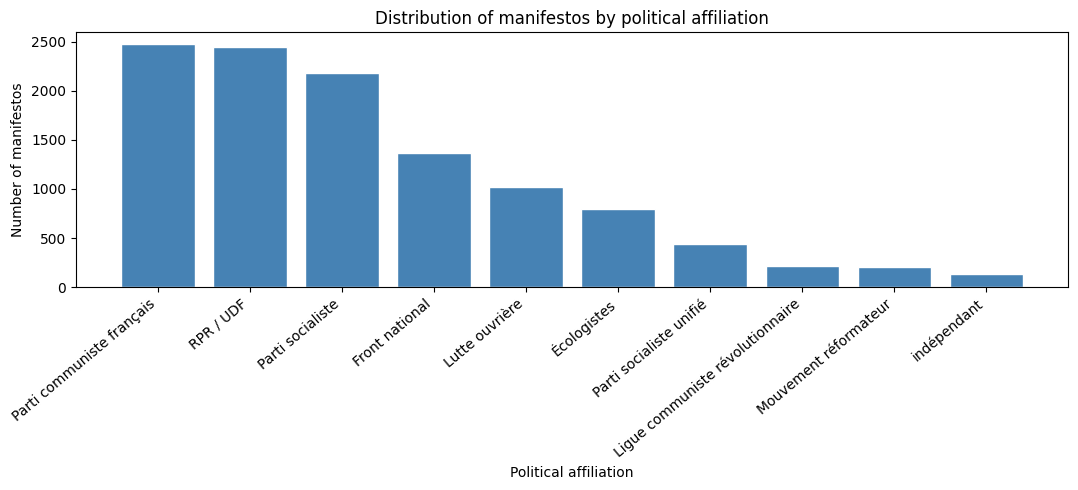

In [11]:
# Class distribution
fig, ax = plt.subplots(figsize=(11, 5))
cp = df_clean[LABEL_COLUMN].value_counts()
ax.bar(cp.index, cp.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Political affiliation')
ax.set_ylabel('Number of manifestos')
ax.set_title('Distribution of manifestos by political affiliation')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('fig_class_distribution.png', dpi=150)
plt.show()

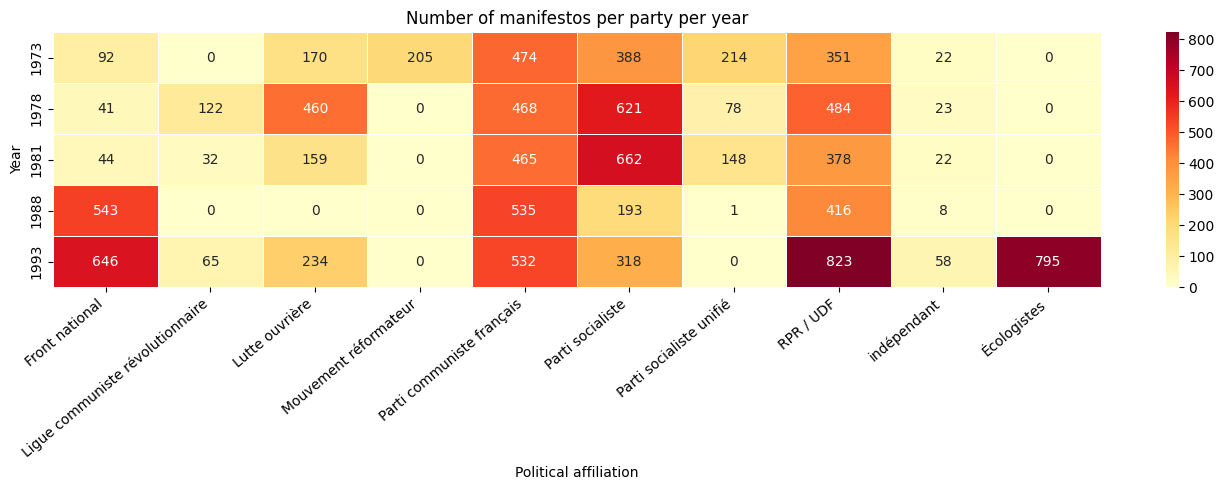

In [12]:
# Manifestos per party per year
pivot = df_clean.groupby(['year', LABEL_COLUMN]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Number of manifestos per party per year')
ax.set_xlabel('Political affiliation')
ax.set_ylabel('Year')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('fig_party_year_heatmap.png', dpi=150)
plt.show()

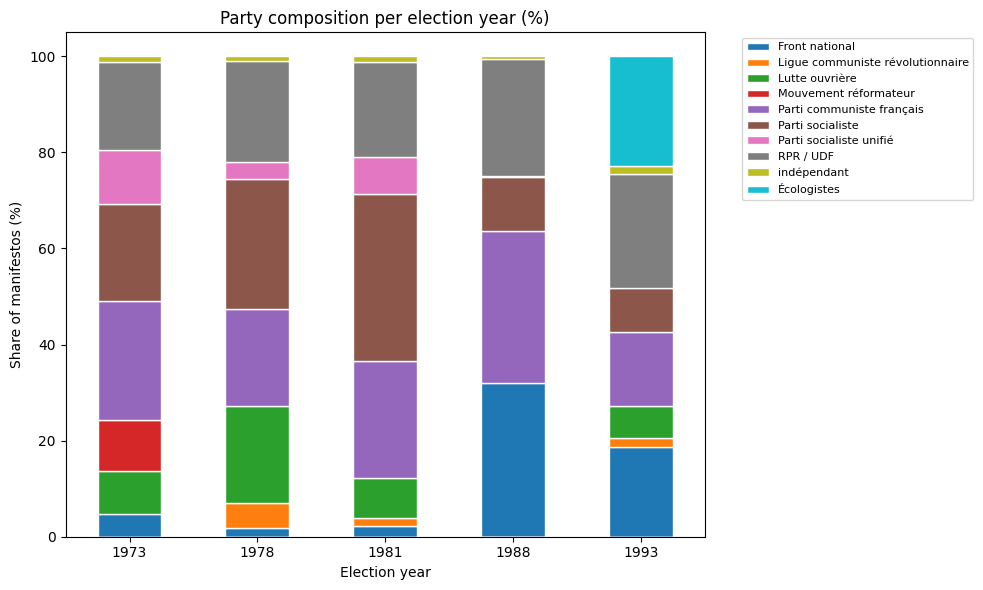

In [13]:
# Party composition per year
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(10, 6))
pivot_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', edgecolor='white')
ax.set_xlabel('Election year')
ax.set_ylabel('Share of manifestos (%)')
ax.set_title('Party composition per election year (%)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('fig_party_year_stacked.png', dpi=150)
plt.show()

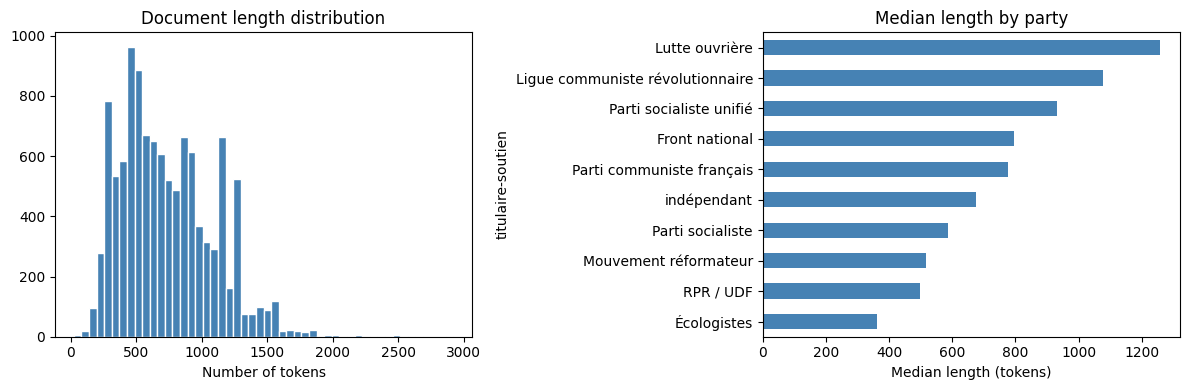

count    11290.000000
mean       737.702303
std        355.500222
min         25.000000
25%        467.250000
50%        677.000000
75%        966.000000
max       2921.000000
Name: doc_length, dtype: float64


In [14]:
# Document length
df_clean['doc_length'] = df_clean['text'].str.split().str.len()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_clean['doc_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Number of tokens')
axes[0].set_title('Document length distribution')
df_clean.groupby(LABEL_COLUMN)['doc_length'].median().sort_values().plot(
    kind='barh', ax=axes[1], color='steelblue')
axes[1].set_xlabel('Median length (tokens)')
axes[1].set_title('Median length by party')
plt.tight_layout()
plt.savefig('fig_doc_length.png', dpi=150)
plt.show()
print(df_clean['doc_length'].describe())

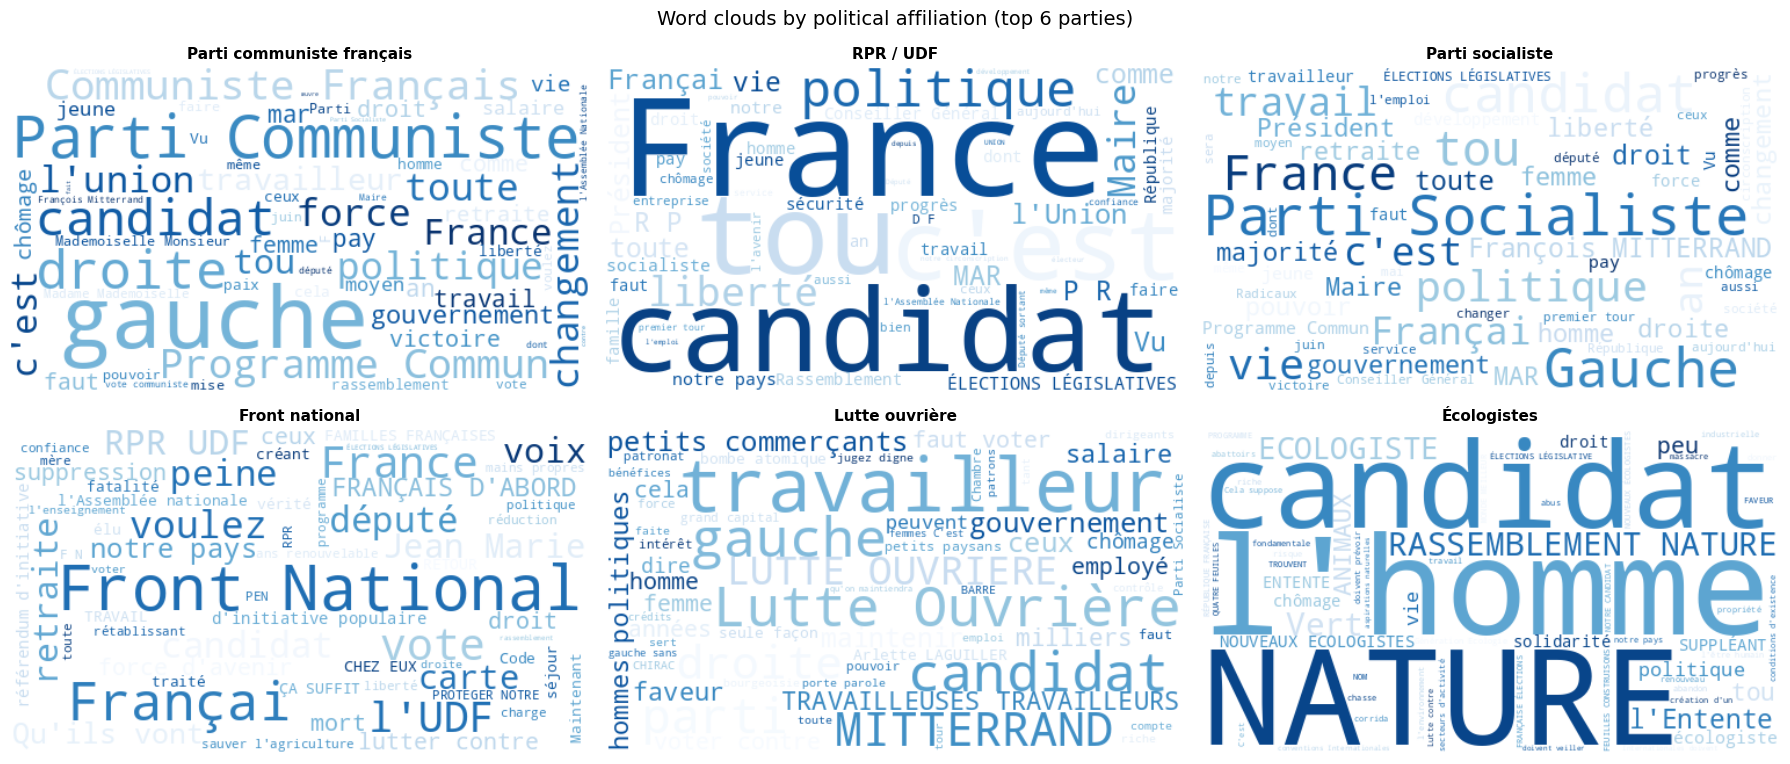

In [15]:
# Word clouds: top 6 parties
top_parties = df_clean[LABEL_COLUMN].value_counts().head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, party in zip(axes.flat, top_parties):
    party_text = ' '.join(df_clean[df_clean[LABEL_COLUMN] == party]['text'].tolist())
    wc = WordCloud(width=500, height=280, background_color='white',
                   stopwords=set(FRENCH_STOPWORDS), max_words=60,
                   colormap='Blues').generate(party_text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(party, fontsize=11, fontweight='bold')
    ax.axis('off')
plt.suptitle('Word clouds by political affiliation (top 6 parties)', fontsize=14)
plt.tight_layout()
plt.savefig('fig_wordclouds.png', dpi=150)
plt.show()

## 4. Preprocessing

**Leakage removal:** party names in manifesto text trivially reveal the label (ex: *communiste* : PCF). I remove them so discriminative features reflect genuine rhetorical differences.

**Language filtering:** Alsace-Moselle candidates wrote partly in German/Alsatian, creating a spurious LDA topic (Topic 3: *die, der, und...*). I filter these out for the LDA analysis while keeping them for classification.

In [16]:
LEAKAGE_TERMS = [
    'communiste', 'parti communiste', 'pcf',
    'parti socialiste', 'socialiste',
    'front national',
    'lutte ouvriere', 'lutte ouvrière',
    'rassemblement pour la republique', 'rpr',
    'union pour la democratie francaise', 'udf',
    'parti socialiste unifie', 'psu',
    'ecologiste', 'generation ecologie', 'verts',
    'mouvement reformateur',
]

def preprocess(text):
    text = text.lower()
    for term in sorted(LEAKAGE_TERMS, key=len, reverse=True):
        text = text.replace(term, ' ')
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return ' '.join([t for t in text.split() if len(t) > 2])

df_clean['text_clean'] = df_clean['text'].apply(preprocess)
print('Leakage removal done.')
print('Example:', df_clean['text_clean'].iloc[0][:300])

Leakage removal done.
Example: republique francaise liberte egalite fraternite departement ain ère circonscription bourg bresse elections législatives mars union gauche democrate mouvement des radicaux gauche sciences fonds cevipof candidat roland mon net ans ingénieur suppleant pierre perrin ans conseiller général madame mademoi


In [17]:
# Language filter: detect documents with German function words
GERMAN_MARKERS = ['der', 'und', 'die', 'das', 'fur', 'von', 'ist', 'den', 'sie', 'ein']

def is_french(text, threshold=3):
    tokens = set(text.lower().split())
    return sum(1 for w in GERMAN_MARKERS if w in tokens) < threshold

mask_french = df_clean['text_clean'].apply(is_french)
print(f'Documents flagged as non-French (Alsatian/German): {(~mask_french).sum()}')
print(f'Documents kept for LDA: {mask_french.sum()}')

df_lda = df_clean[mask_french].copy()
print('\nSplit: df_clean (classification) vs df_lda (topic modeling)')

Documents flagged as non-French (Alsatian/German): 323
Documents kept for LDA: 10967

Split: df_clean (classification) vs df_lda (topic modeling)


In [18]:
X = df_clean['text_clean'].values
y = df_clean[LABEL_COLUMN].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
labels = sorted(list(set(y)))
print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print('Classes:', labels)

Train: 9032 | Test: 2258
Classes: ['Front national', 'Ligue communiste révolutionnaire', 'Lutte ouvrière', 'Mouvement réformateur', 'Parti communiste français', 'Parti socialiste', 'Parti socialiste unifié', 'RPR / UDF', 'indépendant', 'Écologistes']


---
# RQ1 — Can we predict political affiliation from manifesto text?

Five models covering the full spectrum from classic bag-of-words to dense embeddings.

## 5. Model 1 — Naive Bayes (Baseline)

In [19]:
pipe_nb = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2),
                               sublinear_tf=False, min_df=5,
                               stop_words=FRENCH_STOPWORDS)),
    ('clf',   MultinomialNB())
])
pipe_nb.fit(X_train, y_train)
y_pred_nb = pipe_nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)
f1_nb  = f1_score(y_test, y_pred_nb, average='macro')
print(f'Naive Bayes  ->  Accuracy: {acc_nb:.3f} | F1 macro: {f1_nb:.3f}')
print(classification_report(y_test, y_pred_nb))

Naive Bayes  ->  Accuracy: 0.912 | F1 macro: 0.779
                                  precision    recall  f1-score   support

                  Front national       1.00      0.95      0.97       273
Ligue communiste révolutionnaire       0.97      0.86      0.92        44
                  Lutte ouvrière       1.00      1.00      1.00       205
           Mouvement réformateur       1.00      0.24      0.39        41
       Parti communiste français       0.99      0.95      0.97       495
                Parti socialiste       0.86      0.89      0.87       436
         Parti socialiste unifié       1.00      0.74      0.85        88
                       RPR / UDF       0.79      0.99      0.88       490
                     indépendant       0.00      0.00      0.00        27
                     Écologistes       1.00      0.89      0.94       159

                        accuracy                           0.91      2258
                       macro avg       0.86      0.75      

## 6. Model 2 — TF-IDF + Logistic Regression

In [20]:
pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2),
                               sublinear_tf=True, min_df=5,
                               stop_words=FRENCH_STOPWORDS)),
    ('clf',   LogisticRegression(max_iter=1000, class_weight='balanced',
                                  C=1.0, random_state=RANDOM_STATE))
])
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr, average='macro')
print(f'TF-IDF + LR  ->  Accuracy: {acc_lr:.3f} | F1 macro: {f1_lr:.3f}')
print(classification_report(y_test, y_pred_lr))

TF-IDF + LR  ->  Accuracy: 0.973 | F1 macro: 0.950
                                  precision    recall  f1-score   support

                  Front national       1.00      0.98      0.99       273
Ligue communiste révolutionnaire       0.98      0.98      0.98        44
                  Lutte ouvrière       1.00      1.00      1.00       205
           Mouvement réformateur       1.00      0.90      0.95        41
       Parti communiste français       1.00      0.97      0.98       495
                Parti socialiste       0.97      0.96      0.97       436
         Parti socialiste unifié       1.00      0.98      0.99        88
                       RPR / UDF       0.93      0.99      0.96       490
                     indépendant       0.70      0.70      0.70        27
                     Écologistes       0.99      0.97      0.98       159

                        accuracy                           0.97      2258
                       macro avg       0.96      0.94      

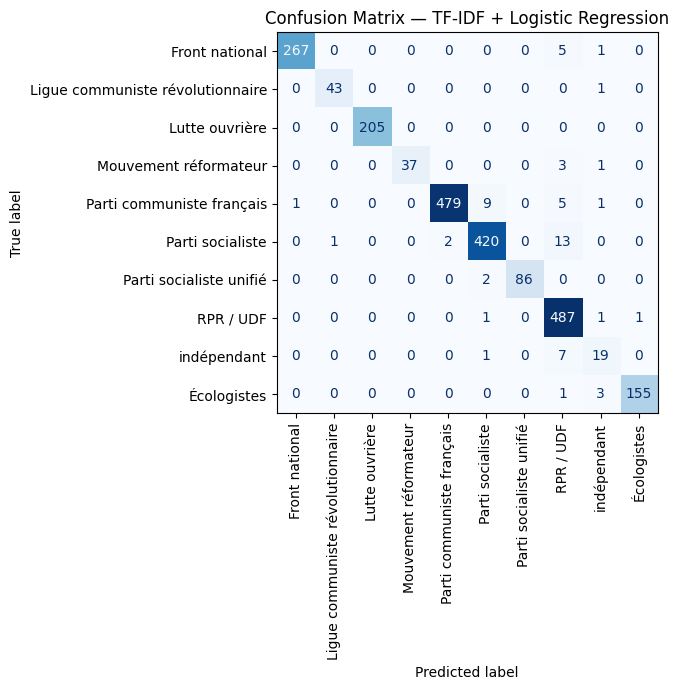

In [21]:
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lr, labels=labels), display_labels=labels
).plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=90)
ax.set_title('Confusion Matrix — TF-IDF + Logistic Regression')
plt.tight_layout()
plt.savefig('fig_cm_lr.png', dpi=150)
plt.show()

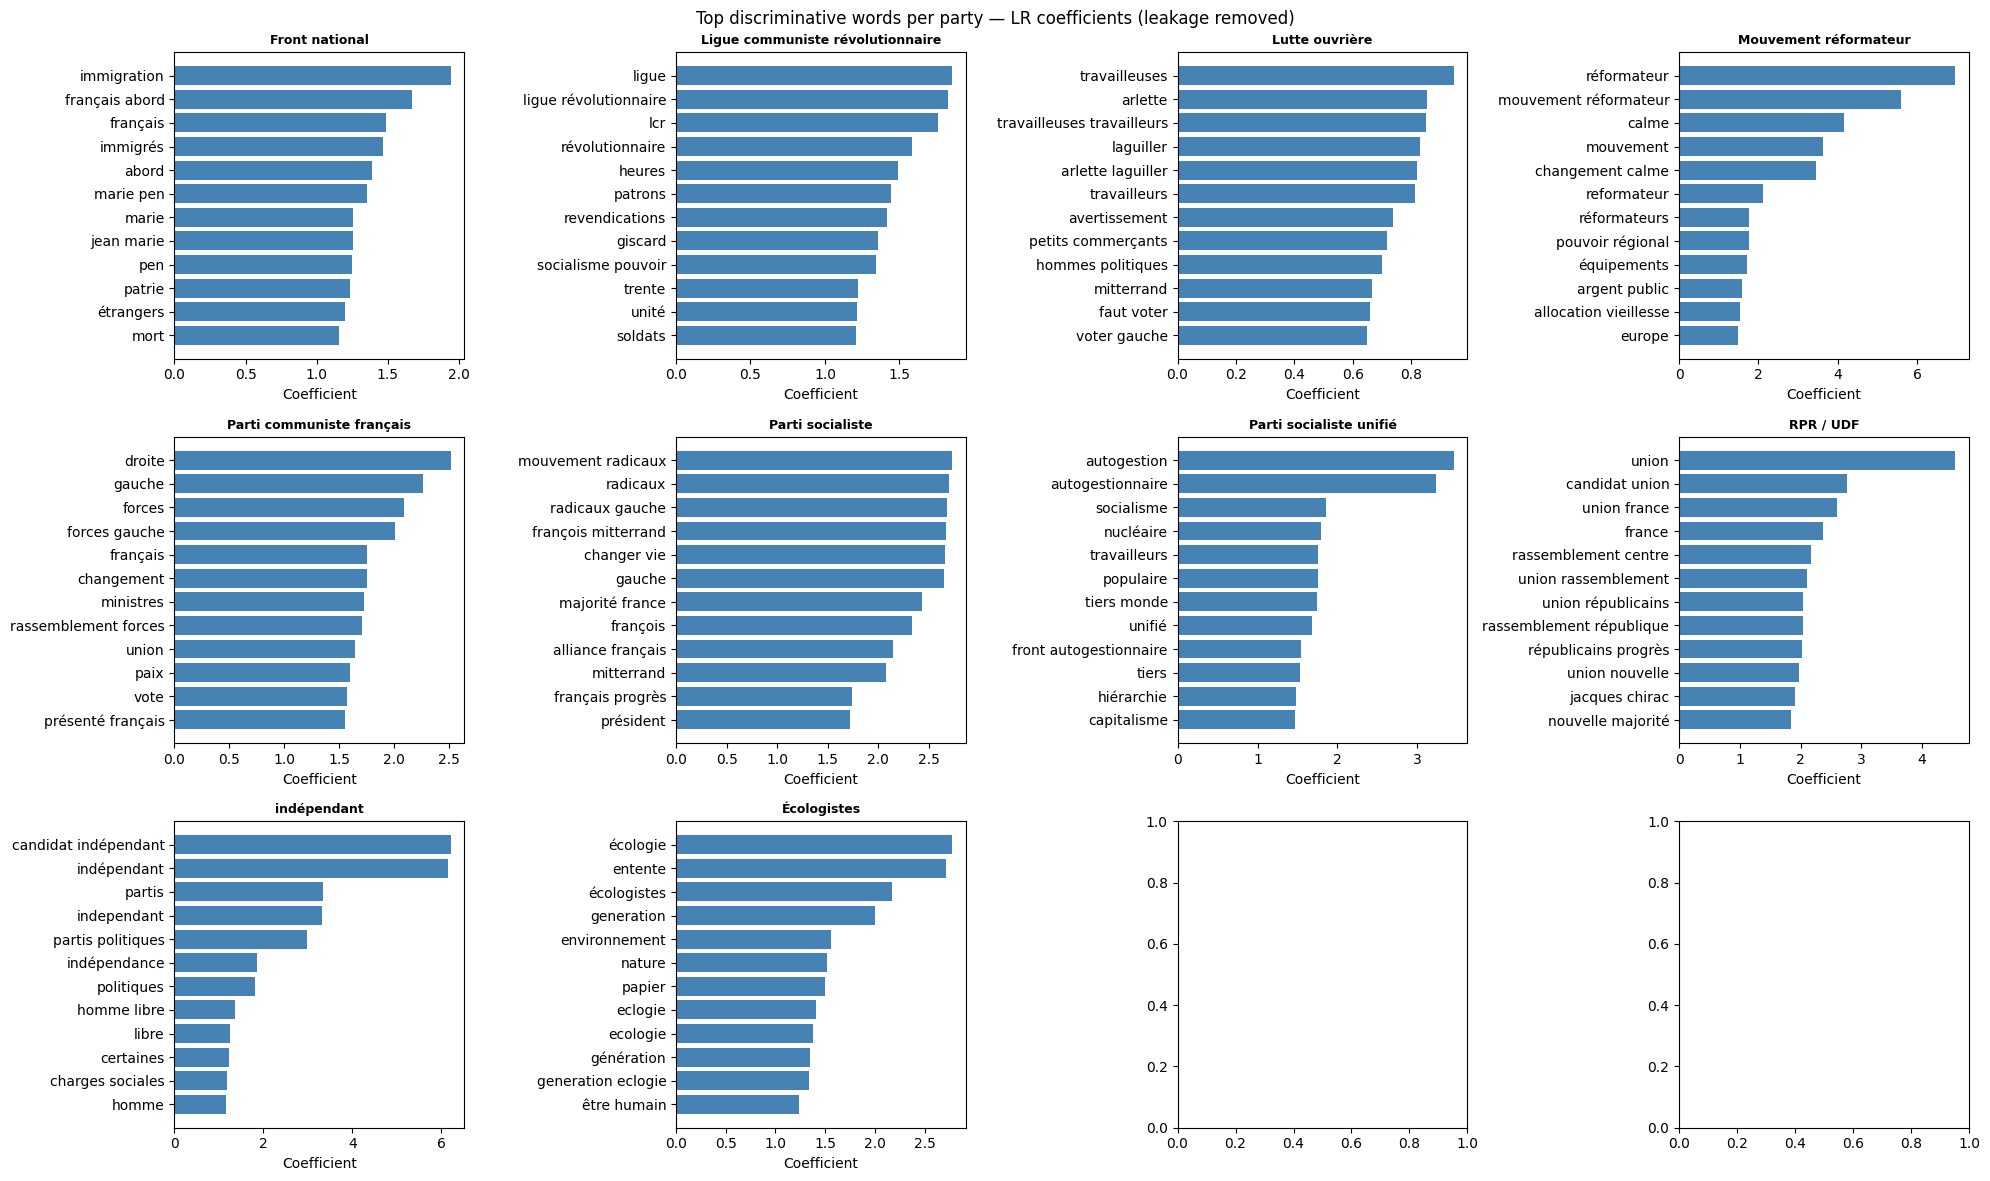

In [22]:
# Top discriminative words per party (LR coefficients)
feature_names = pipe_lr.named_steps['tfidf'].get_feature_names_out()
clf_lr = pipe_lr.named_steps['clf']
N_TOP  = 12
n_cls  = len(clf_lr.classes_)
ncols  = min(4, n_cls)
nrows  = (n_cls + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes_flat  = axes.flat if n_cls > 1 else [axes]
for ax, cls, coef in zip(axes_flat, clf_lr.classes_, clf_lr.coef_):
    top_idx = np.argsort(coef)[-N_TOP:][::-1]
    ax.barh(feature_names[top_idx][::-1], coef[top_idx][::-1], color='steelblue')
    ax.set_title(cls, fontsize=9, fontweight='bold')
    ax.set_xlabel('Coefficient')
for ax in list(axes_flat)[n_cls:]:
    ax.set_visible(False)
plt.suptitle('Top discriminative words per party — LR coefficients (leakage removed)', fontsize=12)
plt.tight_layout()
plt.savefig('fig_top_words.png', dpi=150)
plt.show()

## 7. Model 3 — TF-IDF + Linear SVM

In [23]:
pipe_svm = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2),
                               sublinear_tf=True, min_df=5,
                               stop_words=FRENCH_STOPWORDS)),
    ('clf',   LinearSVC(class_weight='balanced', C=1.0,
                         max_iter=2000, random_state=RANDOM_STATE))
])
pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm  = f1_score(y_test, y_pred_svm, average='macro')
print(f'TF-IDF + SVM  ->  Accuracy: {acc_svm:.3f} | F1 macro: {f1_svm:.3f}')
print(classification_report(y_test, y_pred_svm))

TF-IDF + SVM  ->  Accuracy: 0.978 | F1 macro: 0.963
                                  precision    recall  f1-score   support

                  Front national       0.99      0.99      0.99       273
Ligue communiste révolutionnaire       0.98      0.98      0.98        44
                  Lutte ouvrière       1.00      1.00      1.00       205
           Mouvement réformateur       1.00      0.90      0.95        41
       Parti communiste français       0.99      0.98      0.98       495
                Parti socialiste       0.97      0.97      0.97       436
         Parti socialiste unifié       1.00      0.98      0.99        88
                       RPR / UDF       0.95      0.99      0.97       490
                     indépendant       0.95      0.70      0.81        27
                     Écologistes       1.00      0.99      0.99       159

                        accuracy                           0.98      2258
                       macro avg       0.98      0.95     

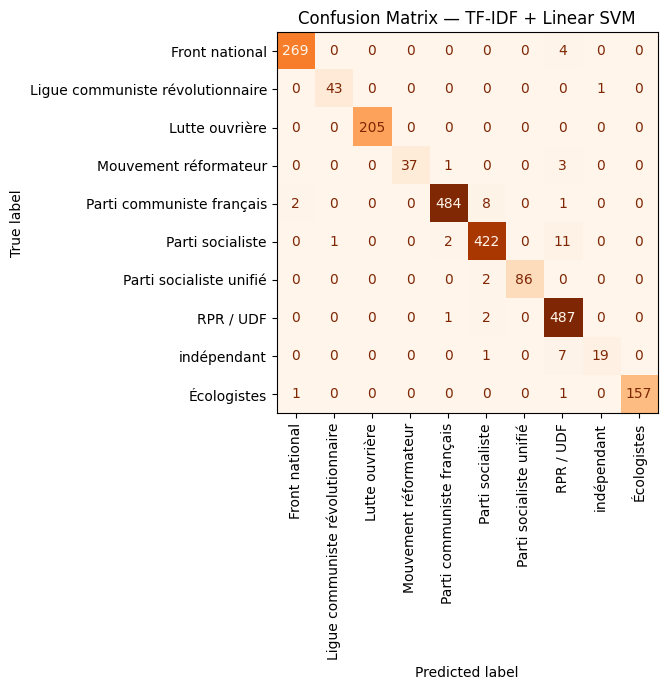

In [24]:
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_svm, labels=labels), display_labels=labels
).plot(ax=ax, cmap='Oranges', colorbar=False, xticks_rotation=90)
ax.set_title('Confusion Matrix — TF-IDF + Linear SVM')
plt.tight_layout()
plt.savefig('fig_cm_svm.png', dpi=150)
plt.show()

## 8. Model 4 — TF-IDF + LSI + Logistic Regression

Truncated SVD applied to the TF-IDF matrix produces dense document representations capturing latent semantic structure. Sits between sparse TF-IDF and neural embeddings.

In [25]:
tfidf_lsi = TfidfVectorizer(max_features=20000, sublinear_tf=True,
                             min_df=5, stop_words=FRENCH_STOPWORDS)
X_train_tfidf = tfidf_lsi.fit_transform(X_train)
X_test_tfidf  = tfidf_lsi.transform(X_test)

svd = TruncatedSVD(n_components=200, random_state=RANDOM_STATE)
X_train_lsi = svd.fit_transform(X_train_tfidf)
X_test_lsi  = svd.transform(X_test_tfidf)
print(f'Explained variance (200 components): {svd.explained_variance_ratio_.sum():.3f}')

lr_lsi = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr_lsi.fit(X_train_lsi, y_train)
y_pred_lsi = lr_lsi.predict(X_test_lsi)
acc_lsi = accuracy_score(y_test, y_pred_lsi)
f1_lsi  = f1_score(y_test, y_pred_lsi, average='macro')
print(f'TF-IDF + LSI + LR  ->  Accuracy: {acc_lsi:.3f} | F1 macro: {f1_lsi:.3f}')
print(classification_report(y_test, y_pred_lsi))

Explained variance (200 components): 0.393
TF-IDF + LSI + LR  ->  Accuracy: 0.943 | F1 macro: 0.905
                                  precision    recall  f1-score   support

                  Front national       1.00      0.95      0.97       273
Ligue communiste révolutionnaire       0.98      0.98      0.98        44
                  Lutte ouvrière       1.00      1.00      1.00       205
           Mouvement réformateur       0.95      0.88      0.91        41
       Parti communiste français       0.99      0.95      0.97       495
                Parti socialiste       0.95      0.91      0.93       436
         Parti socialiste unifié       1.00      0.98      0.99        88
                       RPR / UDF       0.92      0.94      0.93       490
                     indépendant       0.27      0.81      0.40        27
                     Écologistes       0.99      0.94      0.97       159

                        accuracy                           0.94      2258
          

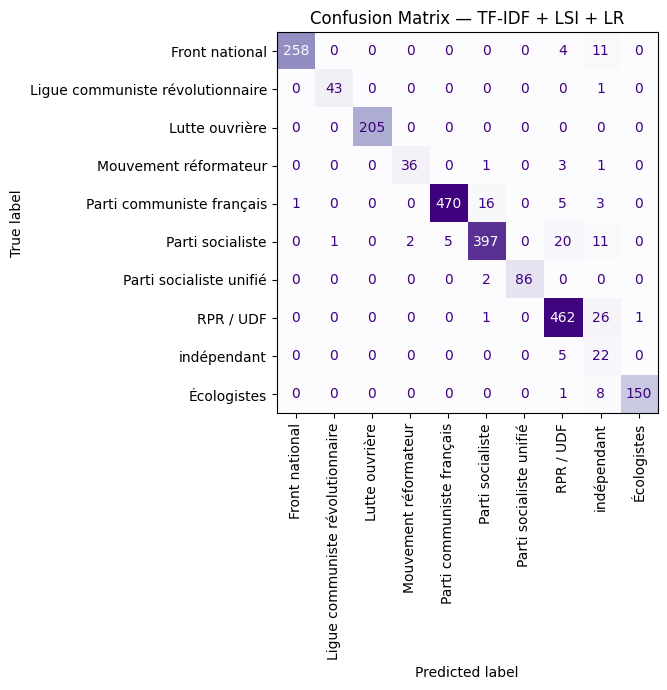

In [26]:
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lsi, labels=labels), display_labels=labels
).plot(ax=ax, cmap='Purples', colorbar=False, xticks_rotation=90)
ax.set_title('Confusion Matrix — TF-IDF + LSI + LR')
plt.tight_layout()
plt.savefig('fig_cm_lsi.png', dpi=150)
plt.show()

## 9. Model 5 — FastText Embeddings + Logistic Regression

FastText (skip-gram with character n-grams) is trained on the training corpus. Document vectors are obtained by averaging word vectors.

In [27]:
sentences = [simple_preprocess(t) for t in X_train]
ft_model = FastText(
    sentences=sentences,
    vector_size=100, window=5, min_count=3,
    epochs=10, sg=1, workers=4
)
print('FastText trained. Vocab size:', len(ft_model.wv))

FastText trained. Vocab size: 34735


In [28]:
def doc_vector(model, text):
    tokens = simple_preprocess(text)
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

X_train_ft = np.array([doc_vector(ft_model, t) for t in X_train])
X_test_ft  = np.array([doc_vector(ft_model, t) for t in X_test])

lr_ft = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr_ft.fit(X_train_ft, y_train)
y_pred_ft = lr_ft.predict(X_test_ft)
acc_ft = accuracy_score(y_test, y_pred_ft)
f1_ft  = f1_score(y_test, y_pred_ft, average='macro')
print(f'FastText + LR  ->  Accuracy: {acc_ft:.3f} | F1 macro: {f1_ft:.3f}')
print(classification_report(y_test, y_pred_ft))

FastText + LR  ->  Accuracy: 0.859 | F1 macro: 0.813
                                  precision    recall  f1-score   support

                  Front national       0.99      0.96      0.97       273
Ligue communiste révolutionnaire       0.95      0.91      0.93        44
                  Lutte ouvrière       1.00      1.00      1.00       205
           Mouvement réformateur       0.42      0.80      0.55        41
       Parti communiste français       0.96      0.92      0.94       495
                Parti socialiste       0.83      0.72      0.77       436
         Parti socialiste unifié       0.93      0.95      0.94        88
                       RPR / UDF       0.86      0.77      0.82       490
                     indépendant       0.14      0.78      0.24        27
                     Écologistes       0.99      0.92      0.95       159

                        accuracy                           0.86      2258
                       macro avg       0.81      0.87    

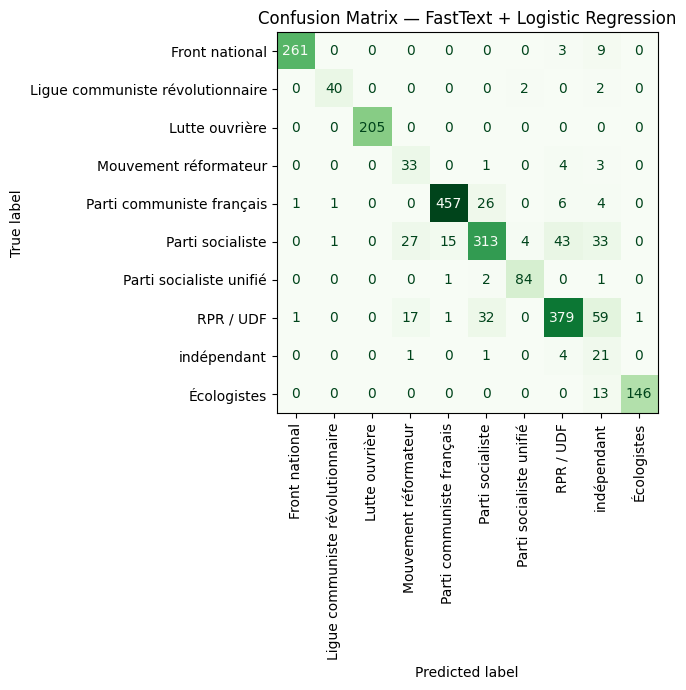

In [29]:
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_ft, labels=labels), display_labels=labels
).plot(ax=ax, cmap='Greens', colorbar=False, xticks_rotation=90)
ax.set_title('Confusion Matrix — FastText + Logistic Regression')
plt.tight_layout()
plt.savefig('fig_cm_ft.png', dpi=150)
plt.show()

## 10. t-SNE of Document Embeddings

2D projection of FastText document embeddings, do parties form separable clusters?

In [30]:
all_vecs   = np.array([doc_vector(ft_model, t) for t in df_clean['text_clean'].values])
all_labels = df_clean[LABEL_COLUMN].values
MAX_TSNE = 2000
if len(all_vecs) > MAX_TSNE:
    idx = np.random.choice(len(all_vecs), MAX_TSNE, replace=False)
    all_vecs, all_labels = all_vecs[idx], all_labels[idx]
print(f'Running t-SNE on {len(all_vecs)} documents...')
X_2d = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30).fit_transform(all_vecs)
print('Done.')

Running t-SNE on 2000 documents...
Done.


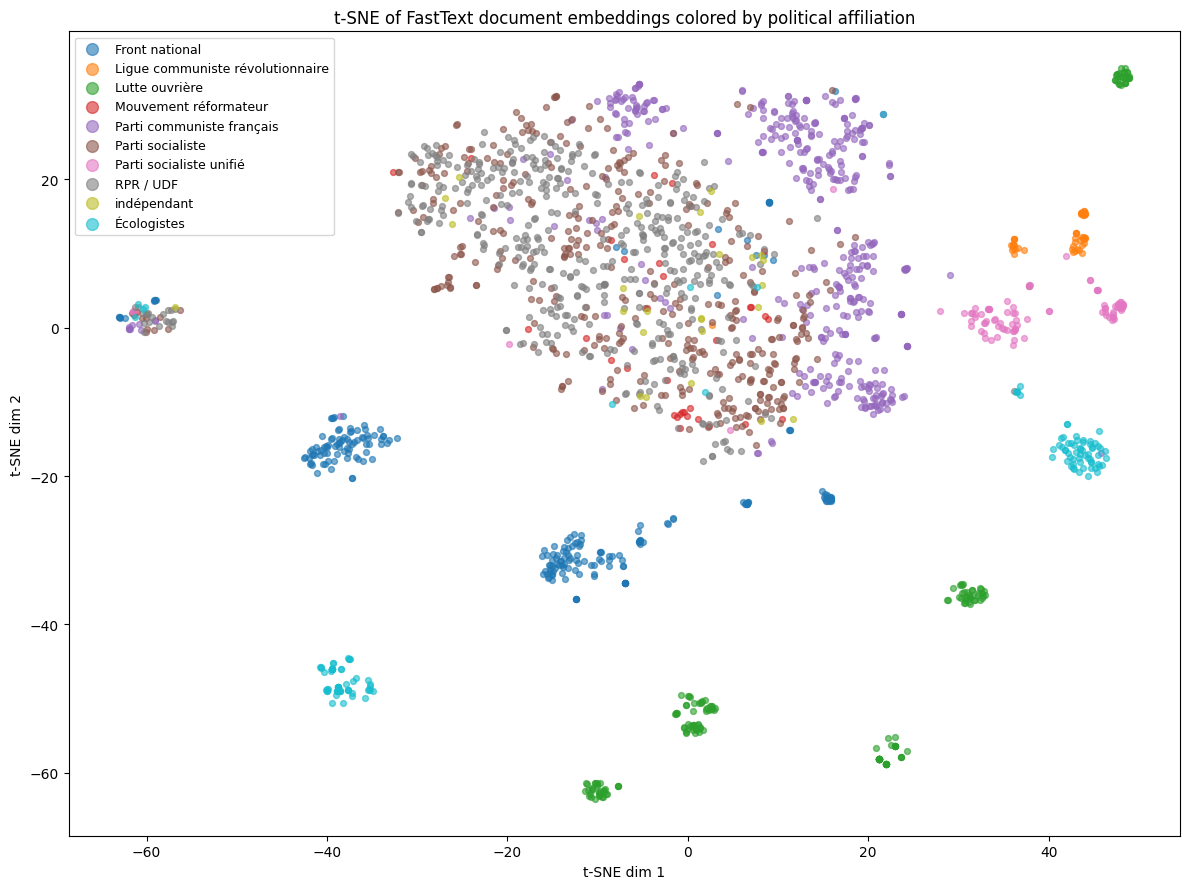

In [31]:
parties_u = sorted(set(all_labels))
colors_u  = cm.tab10(np.linspace(0, 1, len(parties_u)))
cmap_u    = {p: c for p, c in zip(parties_u, colors_u)}
fig, ax = plt.subplots(figsize=(12, 9))
for party in parties_u:
    mask = all_labels == party
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               label=party, alpha=0.6, s=18, color=cmap_u[party])
ax.legend(fontsize=9, markerscale=2)
ax.set_title('t-SNE of FastText document embeddings colored by political affiliation')
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
plt.tight_layout()
plt.savefig('fig_tsne.png', dpi=150)
plt.show()

## 11. RQ1 — Classification Results Summary

In [32]:
res_rand = pd.DataFrame({
    'Model': ['Naive Bayes', 'TF-IDF + LR', 'TF-IDF + SVM',
               'TF-IDF + LSI + LR', 'FastText + LR'],
    'Representation': ['BoW counts', 'TF-IDF sparse', 'TF-IDF sparse',
                        'TF-IDF + SVD dense', 'FastText dense'],
    'Accuracy':   [acc_nb, acc_lr, acc_svm, acc_lsi, acc_ft],
    'F1 (macro)': [f1_nb,  f1_lr,  f1_svm,  f1_lsi,  f1_ft]
})
print(res_rand.to_string(index=False))

            Model     Representation  Accuracy  F1 (macro)
      Naive Bayes         BoW counts  0.912312    0.779311
      TF-IDF + LR      TF-IDF sparse  0.973428    0.950098
     TF-IDF + SVM      TF-IDF sparse  0.978299    0.962770
TF-IDF + LSI + LR TF-IDF + SVD dense  0.942870    0.904808
    FastText + LR     FastText dense  0.858725    0.813205


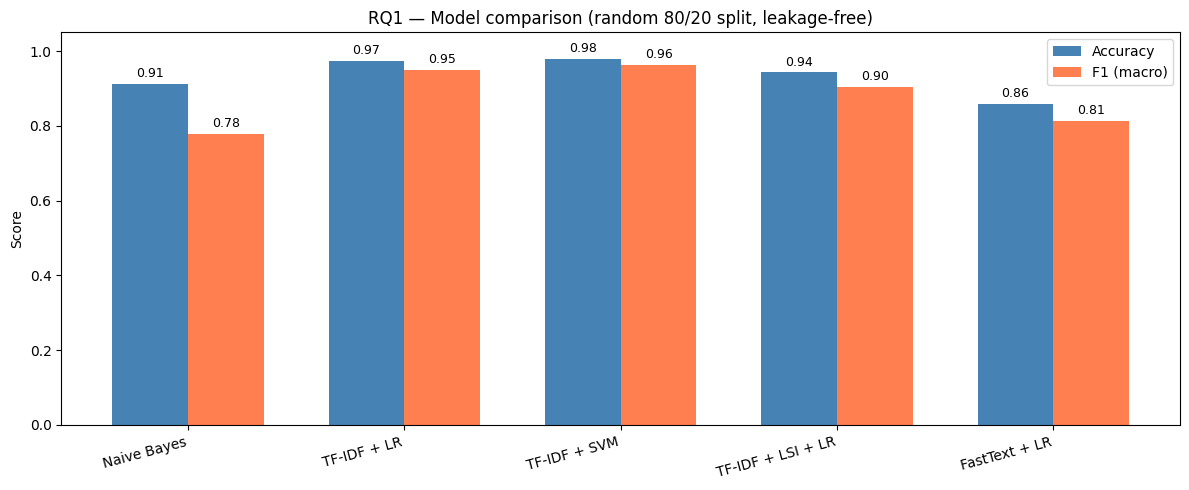

In [33]:
x = np.arange(len(res_rand))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - w/2, res_rand['Accuracy'],   w, label='Accuracy',   color='steelblue')
b2 = ax.bar(x + w/2, res_rand['F1 (macro)'], w, label='F1 (macro)', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(res_rand['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('RQ1 — Model comparison (random 80/20 split, leakage-free)')
ax.legend()
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
            f'{b.get_height():.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('fig_rq1_comparison.png', dpi=150)
plt.show()

In [34]:
errors = pd.DataFrame({'true': y_test, 'predicted': y_pred_svm})
errors = errors[errors['true'] != errors['predicted']]
print('Top misclassification pairs (TF-IDF + SVM):')
print(errors.groupby(['true', 'predicted']).size().sort_values(ascending=False).head(12))

Top misclassification pairs (TF-IDF + SVM):
true                       predicted                       
Parti socialiste           RPR / UDF                           11
Parti communiste français  Parti socialiste                     8
indépendant                RPR / UDF                            7
Front national             RPR / UDF                            4
Mouvement réformateur      RPR / UDF                            3
Parti socialiste unifié    Parti socialiste                     2
RPR / UDF                  Parti socialiste                     2
Parti socialiste           Parti communiste français            2
Parti communiste français  Front national                       2
Parti socialiste           Ligue communiste révolutionnaire     1
Parti communiste français  RPR / UDF                            1
Mouvement réformateur      Parti communiste français            1
dtype: int64


---
# RQ2 — Do politically close parties share a similar rhetorical space?

I apply **LDA topic modeling** on French-only documents, name the topics manually, then build a **semantic map** using the 2 most discriminating LDA topics as axes, directly interpretable, unlike t-SNE projections.

**Key prediction:** parties that are close in topic space should match the confusion pairs in RQ1.

## 12. LDA Topic Modeling

In [35]:
# LDA on French-only documents (df_lda, German/Alsacien filtered out)
count_vec = CountVectorizer(max_features=5000, min_df=5,
                             stop_words=FRENCH_STOPWORDS)
X_counts = count_vec.fit_transform(df_lda['text_clean'])

N_TOPICS = 8
lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=RANDOM_STATE,
    max_iter=20, learning_method='online'
)
W = lda.fit_transform(X_counts)
print(f'LDA trained on {len(df_lda)} French documents. Shape: {W.shape}')

LDA trained on 10967 French documents. Shape: (10967, 8)


In [36]:
feat_names = count_vec.get_feature_names_out()
print('Top words per topic (inspect to assign labels):')
for idx, topic in enumerate(lda.components_):
    top_words = [feat_names[i] for i in topic.argsort()[-12:][::-1]]
    print(f'  Topic {idx}: {", ".join(top_words)}')

Top words per topic (inspect to assign labels):
  Topic 0: français, notre, france, immigration, ans, écologistes, votez, chômage, immigrés, voulez, impôts, contre
  Topic 1: gauche, droite, politique, programme, commun, votre, vie, français, changement, gouvernement, pouvoir, contre
  Topic 2: travailleurs, faire, patrons, tous, entreprises, comme, maintenir, emplois, patronat, payer, faut, chômage
  Topic 3: travailleurs, gauche, mitterrand, voter, contre, comme, petits, droite, marchais, aussi, faut, même
  Topic 4: notre, france, circonscription, tous, majorité, candidat, politique, votre, nos, ans, maire, député
  Topic 5: nature, animaux, nouveaux, rassemblement, marseille, doivent, activités, homme, notre, existence, candidat, suppléant
  Topic 6: nationale, vote, avenir, contre, force, français, france, soit, votez, populaire, vos, suppression
  Topic 7: ans, circonscription, suppléant, travailleurs, etat, dire, progrès, candidats, tous, lui, vote, voter


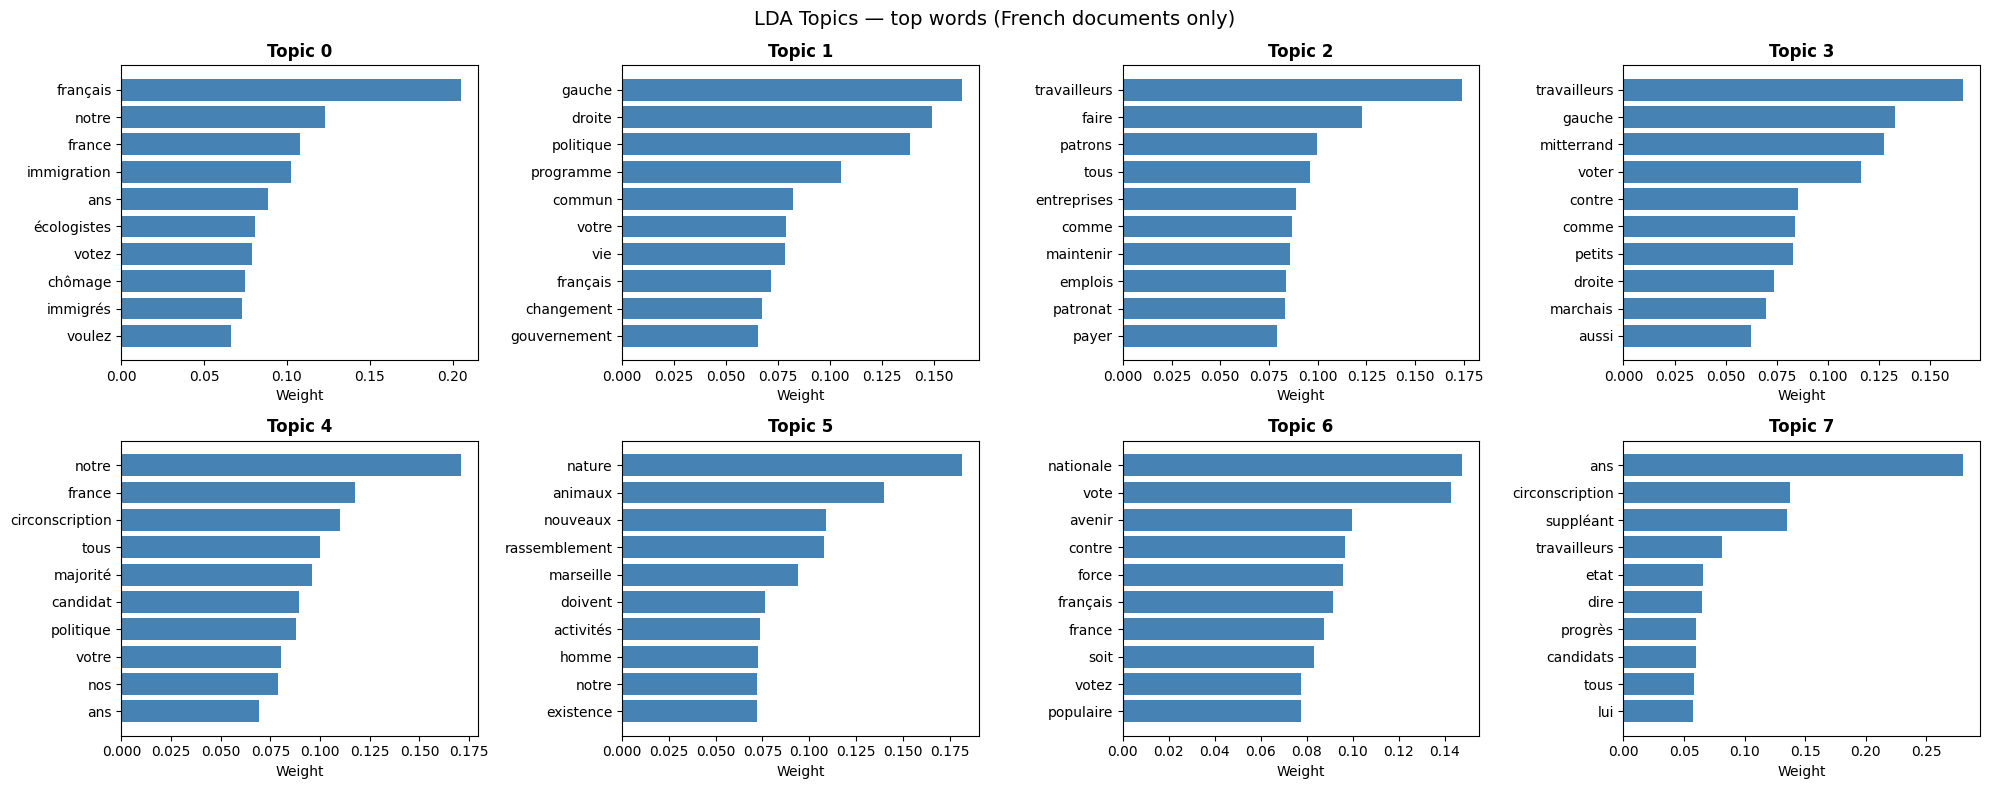

In [37]:
# Top words per topic
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for idx, (ax, topic) in enumerate(zip(axes.flat, lda.components_)):
    top_idx = topic.argsort()[-10:][::-1]
    tw = feat_names[top_idx]
    tv = topic[top_idx] / topic[top_idx].sum()
    ax.barh(tw[::-1], tv[::-1], color='steelblue')
    ax.set_title(f'Topic {idx}', fontweight='bold')
    ax.set_xlabel('Weight')
plt.suptitle('LDA Topics — top words (French documents only)', fontsize=14)
plt.tight_layout()
plt.savefig('fig_lda_topics.png', dpi=150)
plt.show()

In [51]:
# Assign topic labels after inspecting the top words above
TOPIC_LABELS = {
    0: 'Nationalist & immigration (FN)',
    1: 'General left/right discourse',
    2: 'Labour & class struggle',
    3: 'Left electoral appeal (PS/PCF)',
    4: 'Electoral programme (general)',
    5: 'Ecology & nature',
    6: 'Nationalist electoral (RPR/FN)',
    7: 'Local & institutional',
}
print('Topic labels assigned:')
for k, v in TOPIC_LABELS.items():
    print(f'  Topic {k}: {v}')

Topic labels assigned:
  Topic 0: Nationalist & immigration (FN)
  Topic 1: General left/right discourse
  Topic 2: Labour & class struggle
  Topic 3: Left electoral appeal (PS/PCF)
  Topic 4: Electoral programme (general)
  Topic 5: Ecology & nature
  Topic 6: Nationalist electoral (RPR/FN)
  Topic 7: Local & institutional


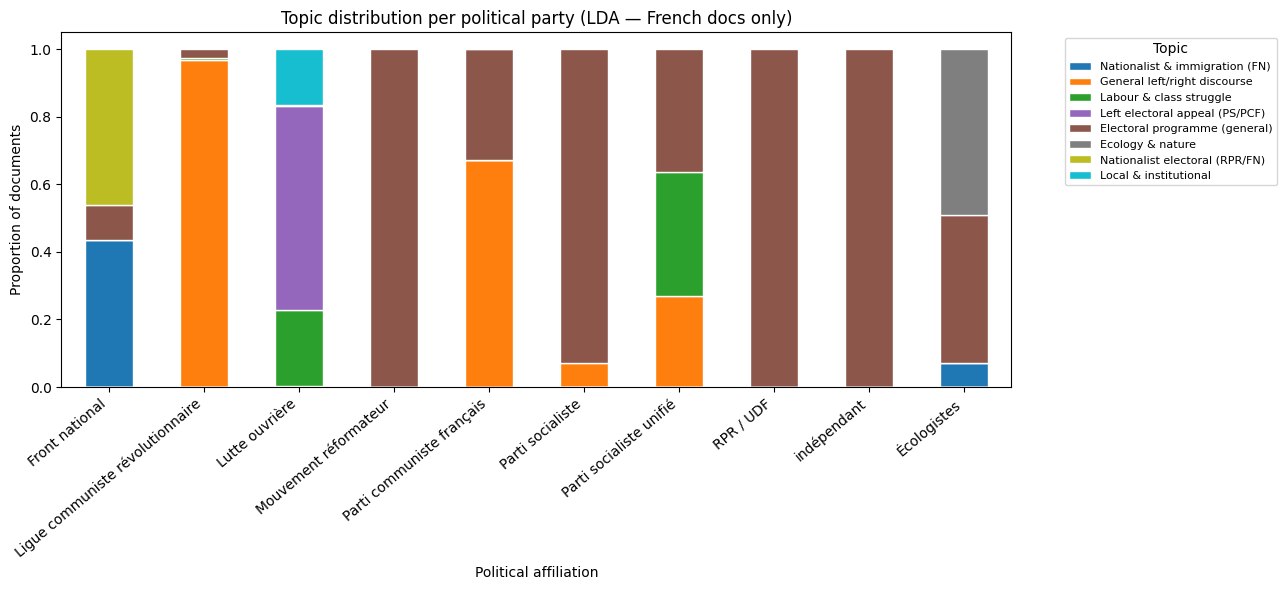

In [39]:
# Topic distribution per party
df_lda = df_lda.copy()
df_lda['dominant_topic'] = W.argmax(axis=1)
topic_party = (
    df_lda.groupby(LABEL_COLUMN)['dominant_topic']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)
# Rename columns with topic labels
topic_party.columns = [TOPIC_LABELS.get(c, f'Topic {c}') for c in topic_party.columns]

# Stacked bar
fig, ax = plt.subplots(figsize=(13, 6))
topic_party.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', edgecolor='white')
ax.set_xlabel('Political affiliation')
ax.set_ylabel('Proportion of documents')
ax.set_title('Topic distribution per political party (LDA — French docs only)')
ax.legend(title='Topic', bbox_to_anchor=(1.05, 1), fontsize=8)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('fig_lda_party_stacked.png', dpi=150)
plt.show()

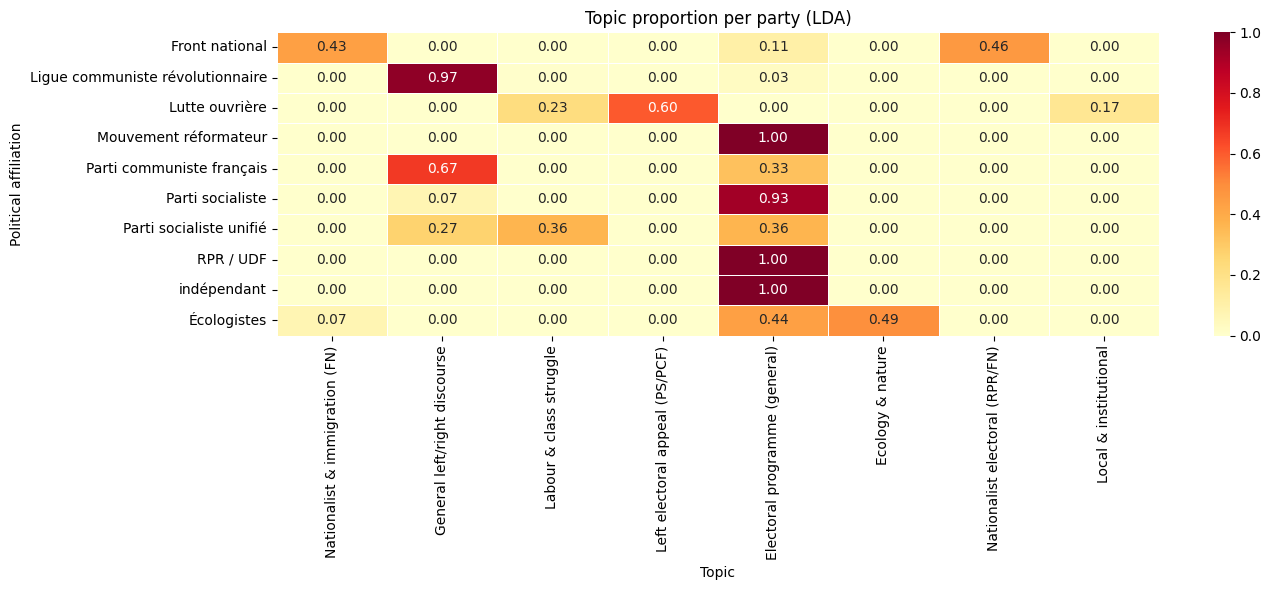

In [40]:
# Topic proportion heatmap
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(topic_party, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Topic proportion per party (LDA)')
ax.set_xlabel('Topic')
ax.set_ylabel('Political affiliation')
plt.tight_layout()
plt.savefig('fig_lda_party_heatmap.png', dpi=150)
plt.show()

## 13. Semantic Map of Political Parties *(RQ2)*

I project party centroids in LDA topic space using the **2 most discriminating topics** as axes (highest variance across party centroids). This is more interpretable than t-SNE because each axis corresponds to a named topic.

In [41]:
# Party centroids in full LDA topic space
lda_labels = sorted(df_lda[LABEL_COLUMN].unique())
party_centroids_lda = {}
for party in lda_labels:
    mask = df_lda[LABEL_COLUMN].values == party
    party_centroids_lda[party] = W[mask].mean(axis=0)

centroid_matrix = np.vstack([party_centroids_lda[p] for p in lda_labels])
print('Centroid matrix shape:', centroid_matrix.shape)

Centroid matrix shape: (10, 8)


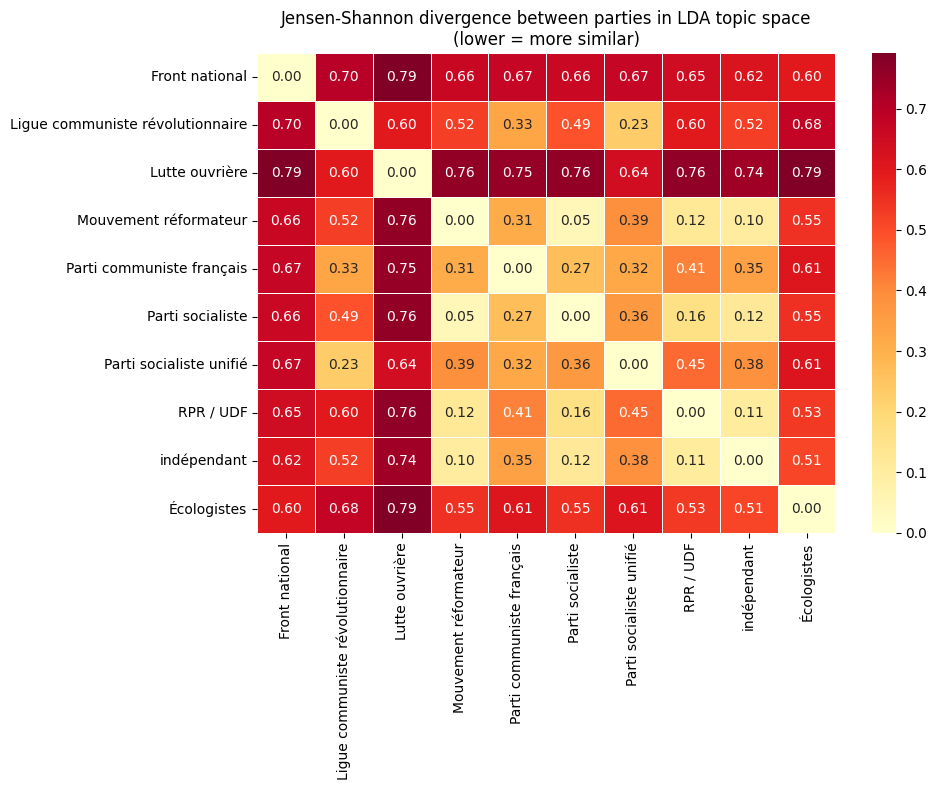

In [42]:
n = len(lda_labels)
js_matrix = np.zeros((
    n, n))
for i in range(n):
    for j in range(n):
        js_matrix[i, j] = jensenshannon(centroid_matrix[i], centroid_matrix[j])

js_df = pd.DataFrame(js_matrix, index=lda_labels, columns=lda_labels)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(js_df, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=ax, linewidths=0.5)
ax.set_title('Jensen-Shannon divergence between parties in LDA topic space\n(lower = more similar)')
plt.tight_layout()
plt.savefig('fig_party_jsd.png', dpi=150)
plt.show()

Most discriminating topics: 4 (Electoral programme (general)) & 1 (General left/right discourse)


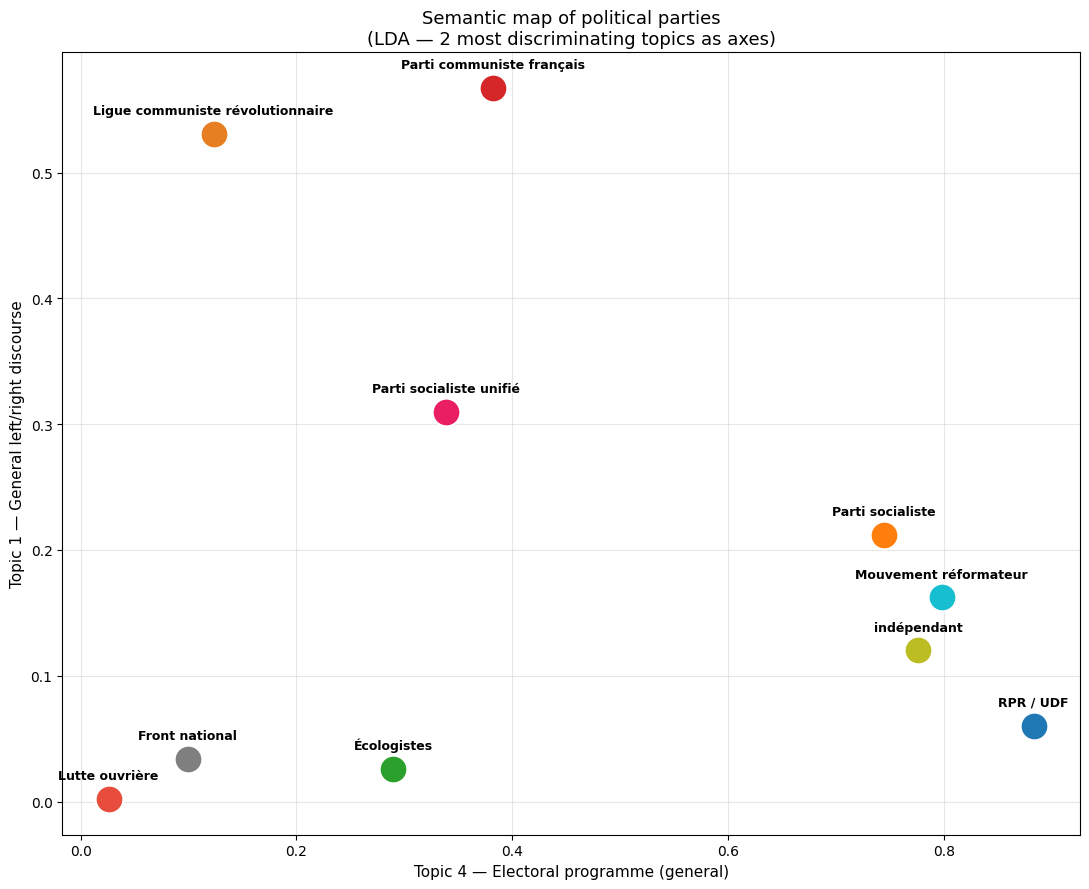

In [43]:
# 2D semantic map: axes = 2 most discriminating topics
topic_variance = centroid_matrix.var(axis=0)
top2 = topic_variance.argsort()[-2:][::-1]
print(f'Most discriminating topics: {top2[0]} ({TOPIC_LABELS[top2[0]]}) '
      f'& {top2[1]} ({TOPIC_LABELS[top2[1]]})')

BLOC_COLORS = {
    'Parti communiste français':        '#d62728',
    'Ligue communiste révolutionnaire': '#e67e22',
    'Lutte ouvrière':                   '#e74c3c',
    'Parti socialiste unifié':          '#e91e63',
    'Parti socialiste':                 '#ff7f0e',
    'Écologistes':                      '#2ca02c',
    'Mouvement réformateur':            '#17becf',
    'RPR / UDF':                        '#1f77b4',
    'Front national':                   '#7f7f7f',
    'indépendant':                      '#bcbd22',
}

fig, ax = plt.subplots(figsize=(11, 9))
for i, party in enumerate(lda_labels):
    color = BLOC_COLORS.get(party, 'black')
    x = centroid_matrix[i, top2[0]]
    y = centroid_matrix[i, top2[1]]
    ax.scatter(x, y, s=400, color=color, zorder=3, edgecolors='white', linewidths=1.5)
    ax.annotate(party, (x, y), fontsize=9, ha='center', va='bottom',
                xytext=(0, 12), textcoords='offset points', fontweight='bold')

ax.set_xlabel(f'Topic {top2[0]} — {TOPIC_LABELS[top2[0]]}', fontsize=11)
ax.set_ylabel(f'Topic {top2[1]} — {TOPIC_LABELS[top2[1]]}', fontsize=11)
ax.set_title('Semantic map of political parties\n(LDA — 2 most discriminating topics as axes)',
             fontsize=13)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_semantic_map.png', dpi=150)
plt.show()

In [44]:
print('Most similar party pairs (lowest JSD in LDA topic space):')
js_pairs = []
for i, p1 in enumerate(lda_labels):
    for j, p2 in enumerate(lda_labels):
        if i < j:
            js_pairs.append((js_df.loc[p1, p2], p1, p2))
for score, p1, p2 in sorted(js_pairs)[:8]:
    print(f'  JSD={score:.3f}  {p1}  <->  {p2}')

print('\nTop confusion pairs (TF-IDF + SVM):')
print(errors.groupby(['true', 'predicted']).size().sort_values(ascending=False).head(8))

Most similar party pairs (lowest JSD in LDA topic space):
  JSD=0.048  Mouvement réformateur  <->  Parti socialiste
  JSD=0.103  Mouvement réformateur  <->  indépendant
  JSD=0.106  RPR / UDF  <->  indépendant
  JSD=0.118  Parti socialiste  <->  indépendant
  JSD=0.123  Mouvement réformateur  <->  RPR / UDF
  JSD=0.163  Parti socialiste  <->  RPR / UDF
  JSD=0.229  Ligue communiste révolutionnaire  <->  Parti socialiste unifié
  JSD=0.269  Parti communiste français  <->  Parti socialiste

Top confusion pairs (TF-IDF + SVM):
true                       predicted                
Parti socialiste           RPR / UDF                    11
Parti communiste français  Parti socialiste              8
indépendant                RPR / UDF                     7
Front national             RPR / UDF                     4
Mouvement réformateur      RPR / UDF                     3
Parti socialiste unifié    Parti socialiste              2
RPR / UDF                  Parti socialiste              2
Part

---
# RQ3 — Does political vocabulary remain stable across decades?

**Two complementary evaluations:**
1. **Direct temporal split:** train on 1973-1981, test on 1988-1993
2. **Leave-one-year-out:** for each year, train on all others

**Important caveat:** F1 drop reflects two phenomena:(1) genuine vocabulary drift, and (2) a dramatically changed party landscape (FN ×6.7, PS ÷3.3, Écologistes appearing from scratch, PSU disappearing). These are confounded in the direct split but the LOO isolates the drift better.

## 14. Temporal Generalization — Direct Split

In [45]:
train_years = [1973, 1978, 1981]
test_years  = [1988, 1993]

train_t = df_clean[df_clean['year'].isin(train_years)]
test_t  = df_clean[df_clean['year'].isin(test_years)]

# Keep classes with >= 30 docs in BOTH periods
MIN_TEMPORAL = 30
common = (
    set(train_t[LABEL_COLUMN].value_counts()[lambda x: x >= MIN_TEMPORAL].index) &
    set(test_t[LABEL_COLUMN].value_counts()[lambda x: x >= MIN_TEMPORAL].index)
)
excluded = (
    set(train_t[LABEL_COLUMN].unique()) | set(test_t[LABEL_COLUMN].unique())
) - common

print('Classes kept (>= 30 docs in both periods):', sorted(common))
print('Classes excluded:', excluded)

train_t = train_t[train_t[LABEL_COLUMN].isin(common)]
test_t  = test_t[test_t[LABEL_COLUMN].isin(common)]
print(f'\nTrain: {len(train_t)} | Test: {len(test_t)}')

Classes kept (>= 30 docs in both periods): ['Front national', 'Ligue communiste révolutionnaire', 'Lutte ouvrière', 'Parti communiste français', 'Parti socialiste', 'RPR / UDF', 'indépendant']
Classes excluded: {'Écologistes', 'Parti socialiste unifié', 'Mouvement réformateur'}

Train: 5478 | Test: 4371


In [46]:
pipe_temp = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2),
                               sublinear_tf=True, min_df=5,
                               stop_words=FRENCH_STOPWORDS)),
    ('clf',   LinearSVC(class_weight='balanced', C=1.0,
                         max_iter=2000, random_state=RANDOM_STATE))
])
pipe_temp.fit(train_t['text_clean'], train_t[LABEL_COLUMN])
y_temp = pipe_temp.predict(test_t['text_clean'])

acc_temp = accuracy_score(test_t[LABEL_COLUMN], y_temp)
f1_temp  = f1_score(test
                    _t[LABEL_COLUMN], y_temp, average='macro')
print(f'Temporal SVM (73-81 → 88-93)  ->  Accuracy: {acc_temp:.3f} | F1 macro: {f1_temp:.3f}')
print(classification_report(test_t[LABEL_COLUMN], y_temp))

Temporal SVM (73-81 → 88-93)  ->  Accuracy: 0.720 | F1 macro: 0.507
                                  precision    recall  f1-score   support

                  Front national       1.00      0.78      0.87      1189
Ligue communiste révolutionnaire       1.00      0.02      0.03        65
                  Lutte ouvrière       0.00      0.00      0.00       234
       Parti communiste français       0.78      0.79      0.79      1067
                Parti socialiste       0.36      0.65      0.47       511
                       RPR / UDF       0.72      0.81      0.76      1239
                     indépendant       0.78      0.53      0.63        66

                        accuracy                           0.72      4371
                       macro avg       0.66      0.51      0.51      4371
                    weighted avg       0.73      0.72      0.71      4371



In [47]:
print('Train distribution (1973-1981):')
print(train_t[LABEL_COLUMN].value_counts().to_string())
print('\nTest distribution (1988-1993):')
print(test_t[LABEL_COLUMN].value_counts().to_string())
print('\nConfounding: FN x6.7 | PS /3.3 | LO /3.4 — class shift, not just vocabulary drift.')

Train distribution (1973-1981):
titulaire-soutien
Parti socialiste                    1671
Parti communiste français           1407
RPR / UDF                           1213
Lutte ouvrière                       789
Front national                       177
Ligue communiste révolutionnaire     154
indépendant                           67

Test distribution (1988-1993):
titulaire-soutien
RPR / UDF                           1239
Front national                      1189
Parti communiste français           1067
Parti socialiste                     511
Lutte ouvrière                       234
indépendant                           66
Ligue communiste révolutionnaire      65

Confounding: FN x6.7 | PS /3.3 | LO /3.4 — class shift, not just vocabulary drift.


## 15. Leave-One-Year-Out Evaluation

LOO 1973: F1 = 0.707
LOO 1978: F1 = 0.620
LOO 1981: F1 = 0.793
LOO 1988: F1 = 0.762
LOO 1993: F1 = 0.528


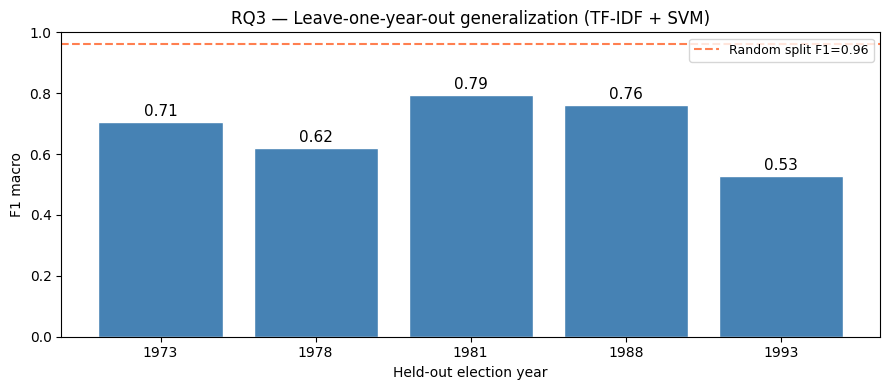

In [48]:
loo_results = []
for test_year in [1973, 1978, 1981, 1988, 1993]:
    tr = df_clean[df_clean['year'] != test_year]
    te = df_clean[df_clean['year'] == test_year]
    common_y = set(tr[LABEL_COLUMN]) & set(te[LABEL_COLUMN])
    tr = tr[tr[LABEL_COLUMN].isin(common_y)]
    te = te[te[LABEL_COLUMN].isin(common_y)]
    p = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2),
                                   sublinear_tf=True, min_df=5,
                                   stop_words=FRENCH_STOPWORDS)),
        ('clf',   LinearSVC(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE))
    ])
    p.fit(tr['text_clean'], tr[LABEL_COLUMN])
    f1 = f1_score(te[LABEL_COLUMN], p.predict(te['text_clean']), average='macro')
    loo_results.append({'year': test_year, 'F1 (macro)': f1})
    print(f'LOO {test_year}: F1 = {f1:.3f}')

loo_df = pd.DataFrame(loo_results)
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(loo_df['year'].astype(str), loo_df['F1 (macro)'],
               color='steelblue', edgecolor='white')
for bar, row in zip(bars, loo_results):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{row['F1 (macro)']:.2f}", ha='center', fontsize=11)
ax.set_xlabel('Held-out election year')
ax.set_ylabel('F1 macro')
ax.set_title('RQ3 — Leave-one-year-out generalization (TF-IDF + SVM)')
ax.set_ylim(0, 1)
ax.axhline(f1_svm, color='coral', linestyle='--', linewidth=1.5, label=f'Random split F1={f1_svm:.2f}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_loo.png', dpi=150)
plt.show()

## 16. Final Results Table

In [49]:
results_all = pd.DataFrame({
    'Model': ['Naive Bayes', 'TF-IDF + LR', 'TF-IDF + SVM',
               'TF-IDF + LSI + LR', 'FastText + LR',
               'SVM temporal (73-81 → 88-93)'],
    'Representation': ['BoW counts', 'TF-IDF sparse', 'TF-IDF sparse',
                        'TF-IDF + SVD', 'FastText dense', 'TF-IDF sparse'],
    'Test set': ['random 80/20'] * 5 + ['1988-1993'],
    'Accuracy':   [acc_nb, acc_lr, acc_svm, acc_lsi, acc_ft, acc_temp],
    'F1 (macro)': [f1_nb,  f1_lr,  f1_svm,  f1_lsi,  f1_ft,  f1_temp]
})
print(results_all.to_string(index=False))

                       Model Representation     Test set  Accuracy  F1 (macro)
                 Naive Bayes     BoW counts random 80/20  0.912312    0.779311
                 TF-IDF + LR  TF-IDF sparse random 80/20  0.973428    0.950098
                TF-IDF + SVM  TF-IDF sparse random 80/20  0.978299    0.962770
           TF-IDF + LSI + LR   TF-IDF + SVD random 80/20  0.942870    0.904808
               FastText + LR FastText dense random 80/20  0.858725    0.813205
SVM temporal (73-81 → 88-93)  TF-IDF sparse    1988-1993  0.719744    0.507242
